In [3]:
from astroquery.vizier import Vizier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Set row limit and the columns
Vizier.ROW_LIMIT = 5000  
catalog = "I/239/hip_main"

# Retrieve the catalog
result = Vizier(columns=["HIP", "Vmag", "Plx", "B-V"]).query_constraints(catalog=catalog)
df = result[0].to_pandas()

In [12]:
df = df.dropna(subset=["Plx", "Vmag", "B-V"])
df = df[df["Plx"] > 0]
# Calculate distance in parsecs
df["Distance_pc"] = 1000 / df["Plx"]

# Calculate absolute magnitude
df["AbsMag"] = df["Vmag"] - 5 * np.log10(df["Distance_pc"] / 10)

In [13]:
print(df)

    HIP   Vmag        Plx    B-V  Distance_pc    AbsMag
0     1   9.10   3.540000  0.482   282.485870  1.845016
1     2   9.27  21.900000  0.999    45.662102  5.972221
2     3   6.61   2.810000 -0.019   355.871887 -1.146469
3     4   8.06   7.750000  0.370   129.032257  2.506509
4     5   8.55   2.870000  0.902   348.432068  0.839409
5     6  12.31  18.799999  1.336    53.191490  8.680790
6     7   9.64  17.740000  0.740    56.369785  5.884768
7     8   9.05   5.170000  1.102   193.423599  2.617453
8     9   8.59   4.810000  1.067   207.900208  2.000726
9    10   8.59  10.760000  0.489    92.936798  3.749062
10   11   7.34   4.290000  0.081   233.100235  0.502286
11   12   8.43   4.060000  1.484   246.305420  1.472631
12   13   8.80   3.490000  1.128   286.532959  1.514128
13   14   7.25   5.110000  1.200   195.694717  0.792104
14   15   8.60   2.450000  1.166   408.163269  0.545831
15   17   8.15   6.150000  0.425   162.601624  2.094375
16   16  11.71   0.530000  0.421  1886.792603  0

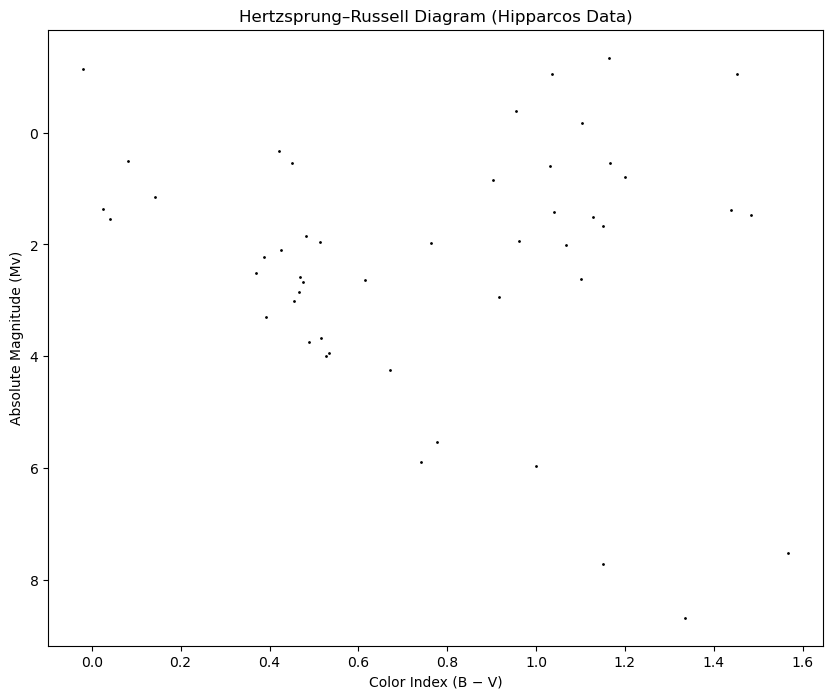

In [14]:
plt.figure(figsize=(10, 8))
plt.scatter(df["B-V"], df["AbsMag"], s=1, color="black")
plt.gca().invert_yaxis()  # Bright stars are lower
plt.xlabel("Color Index (B − V)")
plt.ylabel("Absolute Magnitude (Mv)")
plt.title("Hertzsprung–Russell Diagram (Hipparcos Data)")
plt.show()

In [15]:
df[["B-V", "AbsMag"]].to_csv("hr_diagram_data.csv", index=False)